# Hidden Markov Model with Multivariate Skew‑t Emissions (uMST)

This notebook demonstrates how to **simulate**, **fit**, and **analyze** a 3‑state Hidden Markov Model whose emissions follow the **unrestricted multivariate skew‑t** (Sahu–Dey–Branco, 2003).

It assumes you have your extended `hmmlearn` with `MsktHMM` and the native EMMIXskew library available on your Python path (see README file).

**What you'll see**
1. Generate a synthetic 3‑state uMST‑HMM time series.
2. Fit `MsktHMM`.
3. Compare predicted vs. true states.


In [1]:
import numpy as np

import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

from src.mskt_hmm.mskt_hmm import MsktHMM  
import src.mskt_hmm.native as native
# methods already defined for testing
from src.mskt_hmm.tests.tests_MsktHMM.test_multi_state import best_state_mapping, mark_near_boundaries 
from src.mskt_hmm.native import _safe_sigma_delta, _is_spd
from src.mskt_hmm.utils import _rle
print("src.mskt_hmm.native shared library loaded:", native.LIB is not None)
if native.LIB is None:
    print("\nWARNING: The EMMIXskew shared library was not found by src.mskt_hmm.native.\n"
          "Fitting MsktHMM will fail. Ensure the compiled library "
          "is placed in one of the search paths set in your native.py loader. Check also README file")
    


ModuleNotFoundError: No module named 'mskt_hmm'

## 1) Simulate a 3‑state uMST‑HMM time series

1.1) Hmm variables

In [ ]:
# --- set a reproducible RNG ---
RNG = np.random.default_rng(7)

# --- HMM config ---
T = 10000

states_number = 3
emissions_dimension = 2


startprob = np.array([0.8, 0.15, 0.05])
transmat  = np.array([[0.965, 0.030, 0.005],
                      [0.025, 0.950, 0.025],
                      [0.005, 0.005, 0.990]])

1.2) Emissions variables

In [ ]:
# dof per state
dofs = np.array([4.00, 7.00, 11.00], dtype=float)


# means (mu_k)
means = np.array([
    [ 1.66,  3.08],   
    [ 0.00, -0.09],   
    [-2.85, -1.98],   
], dtype=float)

# skew vectors (delta_k)
deltas = np.array([
    [-1.37, -1.59],  
    [-1.28, 0.42],   
    [0.71, -3.86],  
], dtype=float)




In [ ]:
import numpy as np

# --- Covariances (guess)
covars_guess = np.array([
    # State 0
    [[1.0,  0.3 ],
     [0.3,  1.5]],

    # State 1
    [[1.9, -0.9],
     [-0.9, 1.8]],

    # State 2
    [[0.6,  0.3],
     [0.3,  1.6]],
], dtype=float)



# ---- Preferred: SPD + delta compatibility
covars = np.empty_like(covars_guess)
fixed_flags = []                        # track if a repair happened per state

for k in range(covars_guess.shape[0]):
    Sigma_k, delta_k, fixed = _safe_sigma_delta(
        sigma=covars_guess[k],
        delta=deltas[k]  )
    covars[k] = Sigma_k
    deltas[k] = delta_k
    fixed_flags.append(fixed)

# Sanity checks (using the repo helpers)
all_spd = all(_is_spd(C) for C in covars)
mins = [float(np.min(np.linalg.eigvalsh(C))) for C in covars]
print("All SPD? ", all_spd)
print("Min eigenvalue per state:", mins)
print("Any (Sigma, delta) repair applied per state:", fixed_flags)






All SPD?  True
Min eigenvalue per state: [0.8594875162046672, 0.9486121811340025, 0.51690481051547]
Any (Sigma, delta) repair applied per state: [True, False, True]


1.3) Simulation

In [ ]:
def sample_states(T:int, startprob:np.ndarray, transmat:np.ndarray, RNG):
    """Sample a length‑T state path from a Markov chain."""
    states_number = len(startprob)
    z = np.empty(T, dtype=int)
    z[0] = RNG.choice(states_number, p=startprob)
    for t in range(1, T):
        z[t] = RNG.choice(states_number, p=transmat[z[t-1]])
    return z

def sample_mskt_hmm(T:int, startprob:np.ndarray, transmat:np.ndarray, means:np.ndarray, covars:np.ndarray, deltas:np.ndarray, dofs:np.ndarray, RNG):
    """
    Simulate a uMST-HMM series by generating emissions in blocks over contiguous
    runs of the same hidden state. Uses utils._rle to run-length encode the
    sampled state sequence.

    Parameters
    ----------
    T : int
        Total sequence length.
    startprob : array-like, shape (n_states,)
        Initial state distribution.
    transmat : array-like, shape (n_states, n_states)
        Row-stochastic transition matrix.
    means : array-like, shape (n_states, p)
        Location vectors per state.
    covars : array-like, shape (n_states, p, p)
        Covariance matrices per state.
    deltas : array-like, shape (n_states, p)
        Skewness vectors per state.
    dofs : array-like, shape (n_states,)
        Degrees of freedom per state.
    RNG : np.random.Generator
        Random generator.

    Returns
    -------
    X : ndarray, shape (T, p)
        Simulated observations.
    z : ndarray, shape (T,)
        Simulated hidden state path.
    """
    # 1) sample the Markov chain path
    z = sample_states(T, startprob, transmat, RNG)

    # 2) allocate the observation array
    _, emissions_dimension = means.shape
    X = np.empty((T, emissions_dimension), dtype=float)

    # 3) run-length encode the state path: values=state ids, lengths=run sizes, starts=start indices
    values, lengths, starts = _rle(z)

    # 4) for each contiguous run, draw all emissions with a single call to rdmst
    for k, L, s in zip(values, lengths, starts):
        Y = MsktHMM.rdmst(
            emissions_dimension, n=int(L),
            mean=means[k], cov=covars[k],
            nu=float(dofs[k]), del_=deltas[k],
            rng=RNG
        )
        X[s:s + L, :] = Y

    return X, z




# (Re)generate data with the new emissions
X, z_true = sample_mskt_hmm(T, startprob, transmat, means, covars, deltas, dofs, RNG)
print('X shape:', X.shape, '| z_true shape:', z_true.shape)



X shape: (10000, 2) | z_true shape: (10000,)


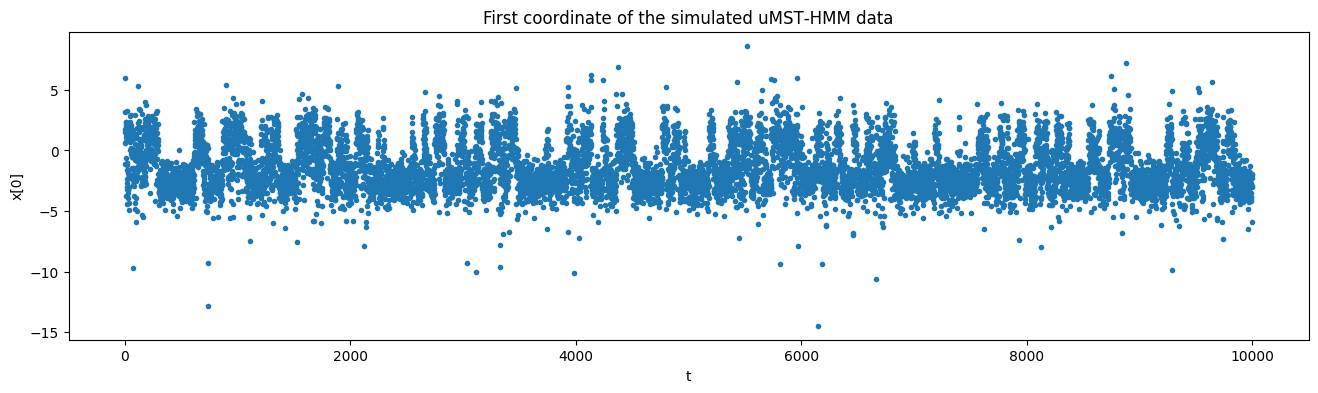

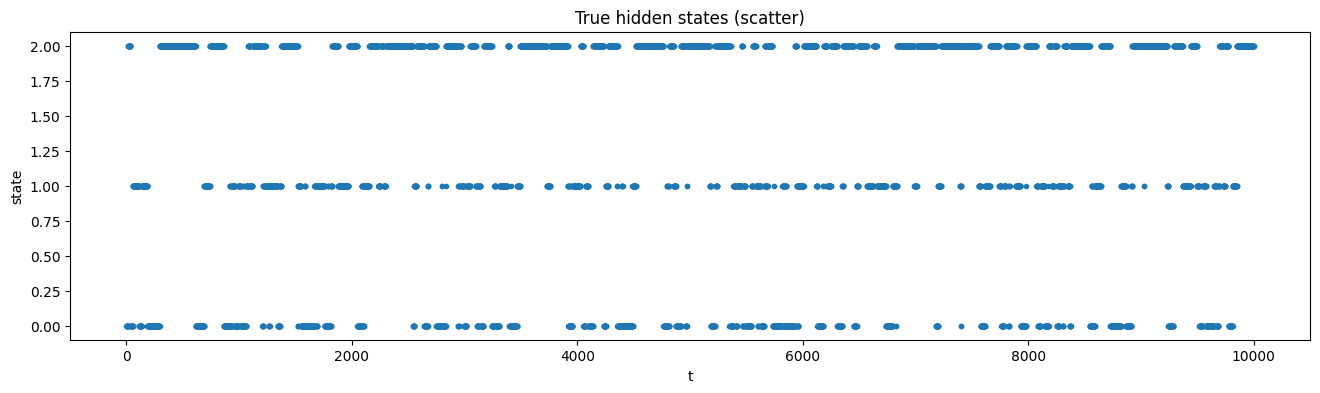

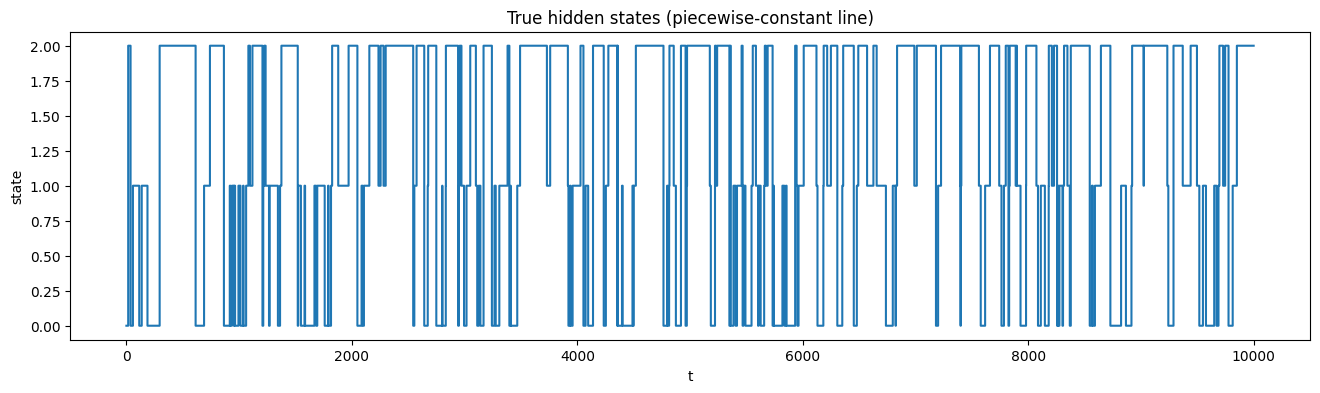

In [ ]:
# Plot the first coordinate over time
plt.figure(figsize=(16, 4))
plt.plot(X[:, 0], '.')
plt.title('First coordinate of the simulated uMST‑HMM data')
plt.xlabel('t'); plt.ylabel('x[0]')
plt.show()

# True hidden states: scatter
plt.figure(figsize=(16, 4))
plt.plot(z_true, '.')
plt.title('True hidden states (scatter)')
plt.xlabel('t'); plt.ylabel('state')
plt.show()

# True hidden states: piecewise-constant (step) curve
plt.figure(figsize=(16, 4))
plt.plot(np.arange(T), z_true, drawstyle='steps-post')
plt.title('True hidden states (piecewise-constant line)')
plt.xlabel('t'); plt.ylabel('state')
plt.show()

## 2) Fit the MsktHMM

In [ ]:
try:
    model = MsktHMM(
        n_components=states_number,
        random_state=RNG.integers(T),
    )

    model.fit(X)
    score = model.score(X)
    print(f'converged={model.monitor_.converged} | score={score:.3f}')
except RuntimeError as e:
    print('\nFitting failed, likely the native EMMIXskew library is not available.\n', str(e))
    



converged=True | score=-35075.389


## 3) Decode, align to true labels, and compare

In [ ]:
_, z_path = model.decode(X, [len(X)], algorithm="viterbi")
mapping   = best_state_mapping(z_true, z_path, n_states=states_number)
z_aligned = np.vectorize(mapping.get)(z_path)

# 3) Accuracy / error metrics
err_mask = (z_aligned != z_true)
error_rate = err_mask.sum() / len(err_mask)
acc = 1.0 - error_rate
N = len(z_true)

# Window for "near boundary" evaluation 
NEAR_WIN = max(1, int(len(z_true) / 500))  # e.g., ~0.5% of the sequence length
near_flags = mark_near_boundaries(z_true, win=NEAR_WIN)

tot_err  = int(err_mask.sum())
near_err = int(np.sum(err_mask & near_flags))
far_err  = int(np.sum(err_mask & ~near_flags))




In [ ]:
print("Permutation mapping (pred -> true):", mapping)
print(f"Overall accuracy: {acc*100:.2f}%   |   Error: {(1-acc)*100:.2f}%")
print(f"Near-boundary window: ±{NEAR_WIN} samples")
print(f"Total errors: {tot_err} / {N}  ({100*tot_err/N:.2f}%)")
print(f"near boundary : {near_err}  ({100*near_err/N:.2f}%)")
print(f"far  boundary : {far_err}   ({100*far_err/N:.2f}%)")



Permutation mapping (pred -> true): {0: 0, 1: 1, 2: 2}
Overall accuracy: 98.87%   |   Error: 1.13%
Near-boundary window: ±20 samples
Total errors: 113 / 10000  (1.13%)
near boundary : 113  (1.13%)
far  boundary : 0   (0.00%)


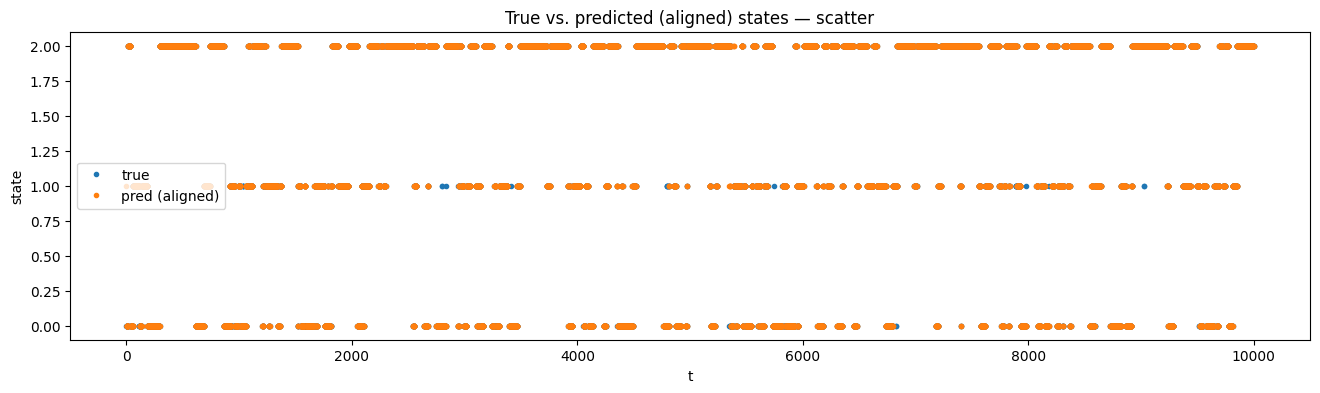

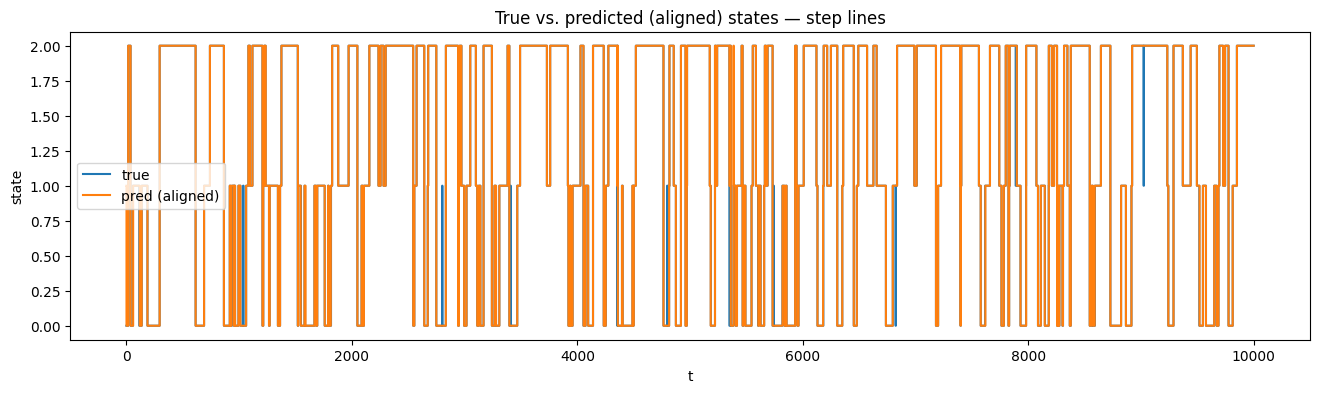

In [ ]:

# 4) Visual comparisons
t = np.arange(len(X))

# (a) scatter
plt.figure(figsize=(16, 4))
plt.plot(z_true, '.', label='true')
plt.plot(z_aligned, '.', label='pred (aligned)')
plt.title('True vs. predicted (aligned) states — scatter')
plt.xlabel('t'); plt.ylabel('state'); plt.legend()
plt.show()

# (b) piecewise-constant (step) curves
plt.figure(figsize=(16, 4))
plt.plot(t, z_true, drawstyle='steps-post', label='true')
plt.plot(t, z_aligned, drawstyle='steps-post', label='pred (aligned)')
plt.title('True vs. predicted (aligned) states — step lines')
plt.xlabel('t'); plt.ylabel('state'); plt.legend()
plt.show()
